# Deteksi Kanker Payudara CBIS-DDSM
## Multi-Model Comparison: EfficientNetB3 · ResNet50V2 · MobileNetV2


## 1 · Instalasi


In [2]:
%pip install kagglehub opencv-python-headless scikit-learn seaborn tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl (40.1 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\USER\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\cv2\\cv2.pyd'
Check the permissions.


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2 · Import & Unduh Dataset


In [3]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.models import Model
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, precision_recall_curve
)
import kagglehub

path = kagglehub.dataset_download('awsaf49/cbis-ddsm-breast-cancer-image-dataset')
print('Dataset path:', path)


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: C:\Users\USER\.cache\kagglehub\datasets\awsaf49\cbis-ddsm-breast-cancer-image-dataset\versions\1


## 3 · Pemuatan & Pemetaan Metadata


In [4]:
csv_dir = os.path.join(path, 'csv')

calc_train = pd.read_csv(os.path.join(csv_dir, 'calc_case_description_train_set.csv'))
calc_test  = pd.read_csv(os.path.join(csv_dir, 'calc_case_description_test_set.csv'))
mass_train = pd.read_csv(os.path.join(csv_dir, 'mass_case_description_train_set.csv'))
mass_test  = pd.read_csv(os.path.join(csv_dir, 'mass_case_description_test_set.csv'))

train_df = pd.concat([calc_train, mass_train], ignore_index=True)
test_df  = pd.concat([calc_test,  mass_test],  ignore_index=True)

def map_images_to_metadata(df, base_path):
    jpeg_dir = os.path.join(base_path, 'jpeg')
    uid_map = {}
    for root, dirs, files in os.walk(jpeg_dir):
        for f in files:
            if f.endswith('.jpg'):
                uid_map[os.path.basename(root)] = os.path.join(root, f)

    def match_path(p):
        if isinstance(p, str):
            for uid in set(p.split('/')):
                if uid in uid_map:
                    return uid_map[uid]
        return None

    df = df.copy()
    df['full_path'] = df['image file path'].apply(match_path)
    df['label']     = df['pathology'].apply(lambda x: 1 if 'MALIGNANT' in str(x) else 0)
    return df.dropna(subset=['full_path']).copy()

train_df_cleaned = map_images_to_metadata(train_df, path)
test_df_cleaned  = map_images_to_metadata(test_df,  path)

print(f'Train: {len(train_df_cleaned)} | Test: {len(test_df_cleaned)}')
print('Label distribusi train:', train_df_cleaned['label'].value_counts().to_dict())


Train: 2864 | Test: 704
Label distribusi train: {0: 1683, 1: 1181}


## 4 · Preprocessing: ROI Extraction + CLAHE


In [5]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

def remove_artifacts_and_extract_roi(image):
    image = np.array(image)
    if image.max() <= 1:
        image = (image * 255).astype(np.uint8)
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    roi = image[cv2.boundingRect(max(contours, key=cv2.contourArea))[1]:,
                cv2.boundingRect(max(contours, key=cv2.contourArea))[0]:] \
          if contours else image
    if contours:
        x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
        roi = image[y:y+h, x:x+w]
    return cv2.resize(roi, IMG_SIZE).astype(np.float32) / 255.0

def preprocess_pipeline(image):
    roi      = remove_artifacts_and_extract_roi(image)
    u8       = np.uint8(roi * 255)
    denoised = cv2.medianBlur(u8, 3)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    channels = [clahe.apply(ch) for ch in cv2.split(denoised)]
    return cv2.merge(channels).astype(np.float32) / 255.0

def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE) / 255.0
    img = tf.py_function(func=preprocess_pipeline, inp=[img], Tout=tf.float32)
    img.set_shape((*IMG_SIZE, 3))
    return img, label

def create_dataset(df, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['full_path'].values, df['label'].values)
    )
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_dataset(train_df_cleaned, shuffle=True)
test_ds  = create_dataset(test_df_cleaned,  shuffle=False)
print('Dataset pipeline siap.')


Dataset pipeline siap.


## 5 · Augmentasi Data


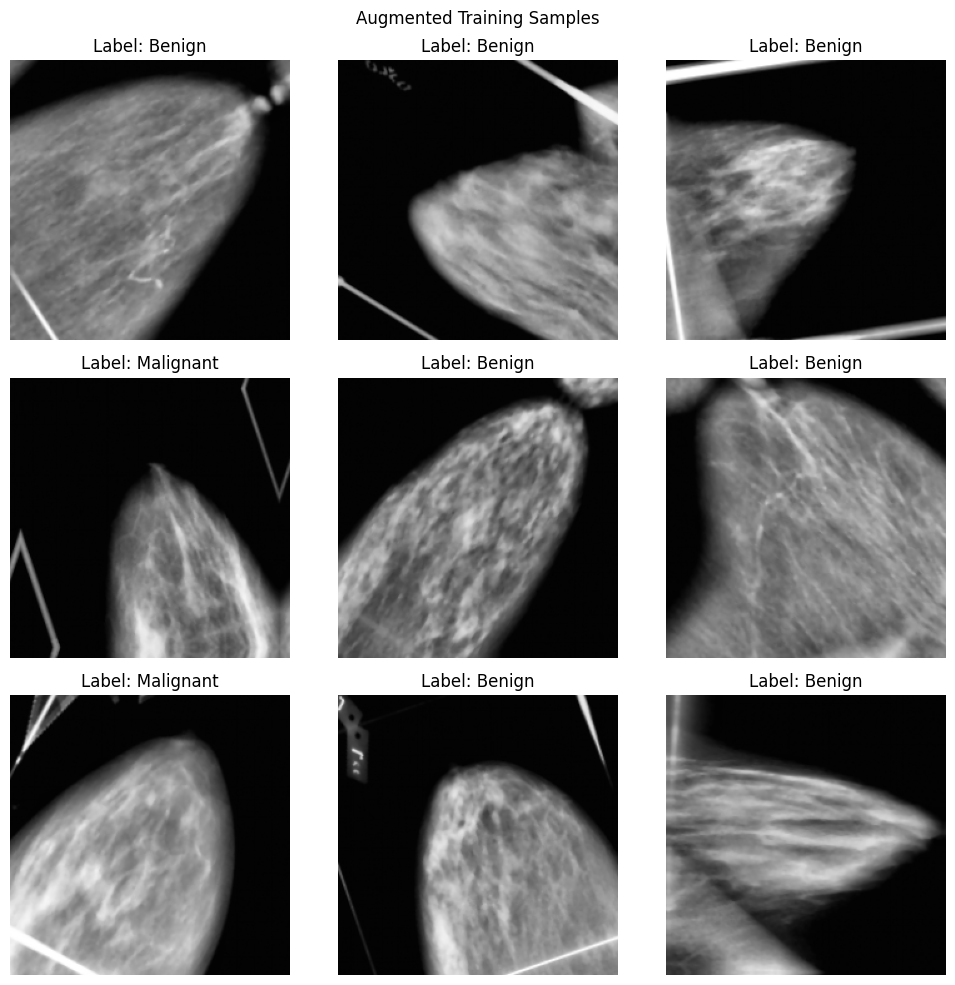

In [6]:
from tensorflow.keras import Sequential

data_augmentation = Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
], name='augmentation')

augmented_train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Visualisasi sampel augmentasi
plt.figure(figsize=(10, 10))
for images, labels in augmented_train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Label: {'Malignant' if labels[i]==1 else 'Benign'}")
        plt.axis('off')
plt.suptitle('Augmented Training Samples')
plt.tight_layout()
plt.show()


## 6 · Fungsi Bantu: Training, Evaluasi, dan Grad-CAM


In [7]:
EPOCHS = 15

# ── Callback bawaan ──
def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(
            monitor='val_auc', patience=5, restore_best_weights=True, mode='max'
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_auc', factor=0.5, patience=3, min_lr=1e-6, mode='max'
        ),
        callbacks.ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_auc', save_best_only=True, mode='max'
        )
    ]

# ── Kompilasi standar ──
def compile_model(model):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.Precision(name='precision')
        ]
    )
    return model

# ── Plot riwayat training ──
def plot_history(history, title=''):
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    auc     = history.history['auc']
    val_auc = history.history['val_auc']
    er      = range(len(acc))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(er, acc,     label='Train Accuracy')
    axes[0].plot(er, val_acc, label='Val Accuracy')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].legend()

    axes[1].plot(er, auc,     label='Train AUC')
    axes[1].plot(er, val_auc, label='Val AUC')
    axes[1].set_title(f'{title} — AUC')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# ── Evaluasi lengkap ──
def evaluate_model(model, dataset, model_name='Model'):
    y_pred_prob = model.predict(dataset).flatten()
    y_pred      = (y_pred_prob > 0.5).astype(int)
    y_true      = np.concatenate([y for _, y in dataset], axis=0)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity  = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity  = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_score    = roc_auc_score(y_true, y_pred_prob)

    print(f'\n{'='*50}')
    print(f'  {model_name} — Hasil Evaluasi')
    print(f'{'='*50}')
    print(f'  Sensitivity (Recall) : {sensitivity:.4f}')
    print(f'  Specificity          : {specificity:.4f}')
    print(f'  AUC (ROC)            : {auc_score:.4f}')
    print(f'\n{classification_report(y_true, y_pred, target_names=["Benign", "Malignant"])}')

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return {'sensitivity': sensitivity, 'specificity': specificity, 'auc': auc_score}

# ── Grad-CAM ──
def get_gradcam(img_array, model, last_conv_layer_name=None):
    if last_conv_layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                last_conv_layer_name = layer.name
                break

    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = tf.reduce_mean(predictions)

    grads       = tape.gradient(loss, conv_outputs)
    pooled      = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap     = conv_outputs[0] @ pooled[..., tf.newaxis]
    heatmap     = tf.squeeze(heatmap)
    heatmap     = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def show_gradcam(model, dataset, model_name='Model'):
    for images, labels in dataset.take(1):
        sample_img   = images[0:1]
        sample_label = labels[0].numpy()
        break

    heatmap = get_gradcam(sample_img, model)
    img_np  = sample_img[0].numpy()
    resized = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy()

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title(f"Original — {'Malignant' if sample_label==1 else 'Benign'}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_np)
    plt.imshow(resized, alpha=0.5, cmap='jet')
    plt.title(f'Grad-CAM — {model_name}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print('Fungsi bantu berhasil didefinisikan.')


Fungsi bantu berhasil didefinisikan.


# ═══════════════════════════════════════════════════════
# MODEL 1 · EfficientNetB3
# Compound scaling — keseimbangan depth, width, resolution
# Rekomendasi utama untuk medical imaging
# ═══════════════════════════════════════════════════════


In [8]:
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB3
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print('Membangun EfficientNetB3 (revisi)...')

def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce    = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t    = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * bce)
    return loss_fn

inputs = layers.Input(shape=(224, 224, 3))
x_in   = layers.Rescaling(scale=255.0)(inputs)  # 0–1 → 0–255

base_efficientnet = EfficientNetB3(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
    # include_preprocessing dihapus — tidak ada di TF < 2.11
)

base_efficientnet.trainable = True
for layer in base_efficientnet.layers[:-50]:
    layer.trainable = False

x = base_efficientnet(x_in, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out_eff = layers.Dense(1, activation='sigmoid', name='output_efficientnet')(x)

model_eff = Model(inputs=inputs, outputs=out_eff, name='EfficientNetB3_v2')

model_eff.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

trainable_count = sum(1 for l in model_eff.layers if l.trainable)
print(f'Trainable layers: {trainable_count}')
model_eff.summary()


Membangun EfficientNetB3 (revisi)...
Trainable layers: 8


Model: "EfficientNetB3_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_efficientnet (Dense)     │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,183,408 (42.66 MB)

 Trainable params: 5,446,965 (20.78 MB)

 Non-trainable params: 5,736,443 (21.88 MB)

=== EfficientNetB3 — Phase 1 ===
Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.5227 - auc: 0.5273 - loss: 0.3312 - precision: 0.4305 - recall: 0.4877 - val_accuracy: 0.6023 - val_auc: 0.5323 - val_loss: 0.0777 - val_precision: 0.3889 - val_recall: 0.0254 - learning_rate: 1.0000e-04
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.5901 - auc: 0.5661 - loss: 0.2026 - precision: 0.5045 - recall: 0.3336 - val_accuracy: 0.5639 - val_auc: 0.5144 - val_loss: 0.0920 - val_precision: 0.2459 - val_recall: 0.0543 - learning_rate: 1.0000e-04
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.5943 - auc: 0.5762 - loss: 0.1914 - precision: 0.5137 - recall: 0.3023 - val_accuracy: 0.5866 - val_auc: 0.5596 - val_loss: 0.1015 - val_precision: 0.4051 - val_recall: 0.1159 - learning_rate: 1.0000e-04
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.5890 - auc: 0.5842 - loss: 0.1872 - precision: 0.5030 - recall: 0.2828 - val_accuracy: 0.6122 -

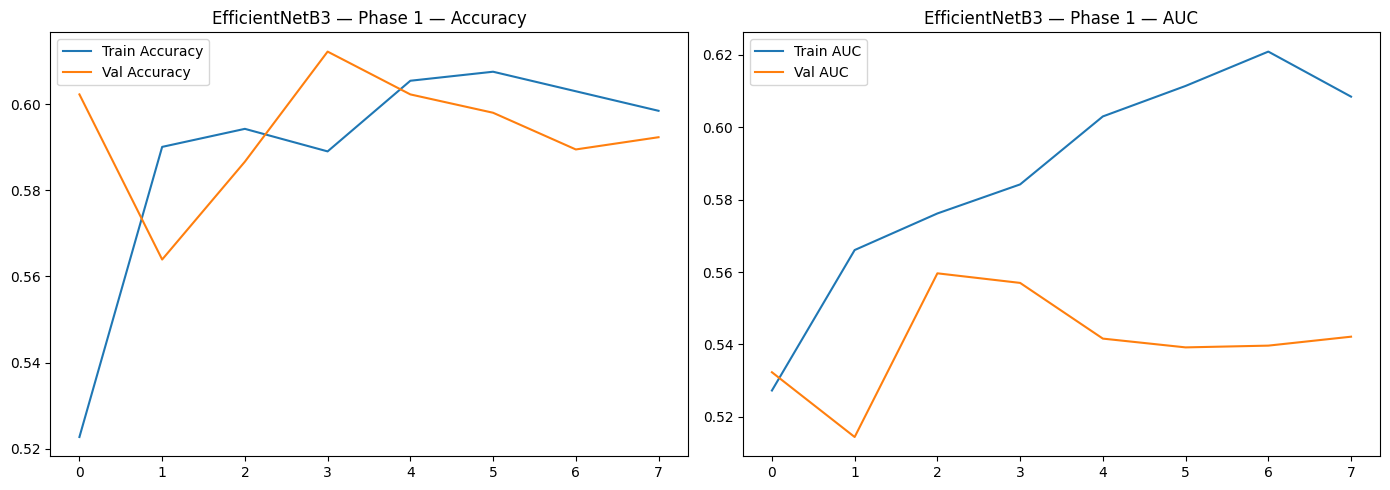

In [9]:
# ── Phase 1: Training dengan 50 layer teratas unfrozen + Focal Loss ──
print('=== EfficientNetB3 — Phase 1 ===')

history_eff_1 = model_eff.fit(
    augmented_train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('efficientnetb3_v2_phase1')
)
plot_history(history_eff_1, 'EfficientNetB3 — Phase 1')


=== EfficientNetB3 — Phase 2: Full Fine-tuning ===
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.5894 - auc: 0.5861 - loss: 0.1872 - precision: 0.5037 - recall: 0.2913 - val_accuracy: 0.5881 - val_auc: 0.5667 - val_loss: 0.1113 - val_precision: 0.4079 - val_recall: 0.1123 - learning_rate: 5.0000e-06
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.6117 - auc: 0.5987 - loss: 0.1814 - precision: 0.5507 - recall: 0.3175 - val_accuracy: 0.5909 - val_auc: 0.5671 - val_loss: 0.1159 - val_precision: 0.4189 - val_recall: 0.1123 - learning_rate: 5.0000e-06
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.6065 - auc: 0.5939 - loss: 0.1789 - precision: 0.5392 - recall: 0.3141 - val_accuracy: 0.5909 - val_auc: 0.5691 - val_loss: 0.1182 - val_precision: 0.4143 - val_recall: 0.1051 - learning_rate: 5.0000e-06
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.5869 - auc: 0.5748 - loss: 0.1862 - precision: 0.4985 - recall: 0.2743 - val_

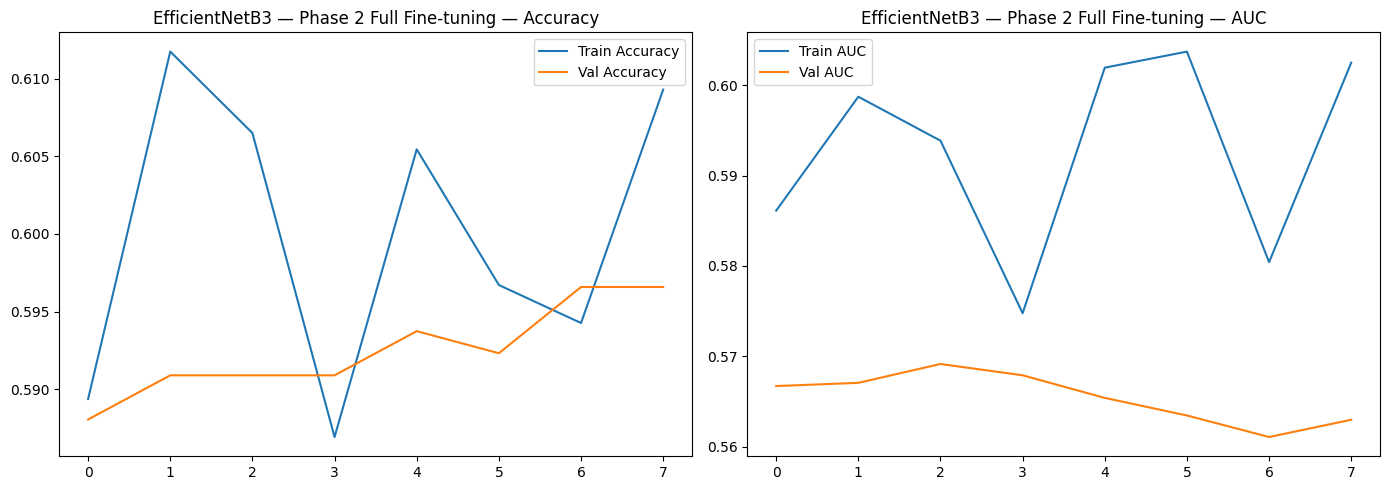

In [10]:
# ── Phase 2: Unfreeze seluruh base model, LR sangat kecil ──
print('=== EfficientNetB3 — Phase 2: Full Fine-tuning ===')

base_efficientnet.trainable = True  # Buka semua layer

model_eff.compile(
    optimizer=optimizers.Adam(learning_rate=5e-6),  # Sangat kecil agar tidak merusak bobot
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

history_eff_2 = model_eff.fit(
    augmented_train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=get_callbacks('efficientnetb3_v2_phase2')
)
plot_history(history_eff_2, 'EfficientNetB3 — Phase 2 Full Fine-tuning')


22/22 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step
Threshold optimal: 0.060  (F1=0.5648)


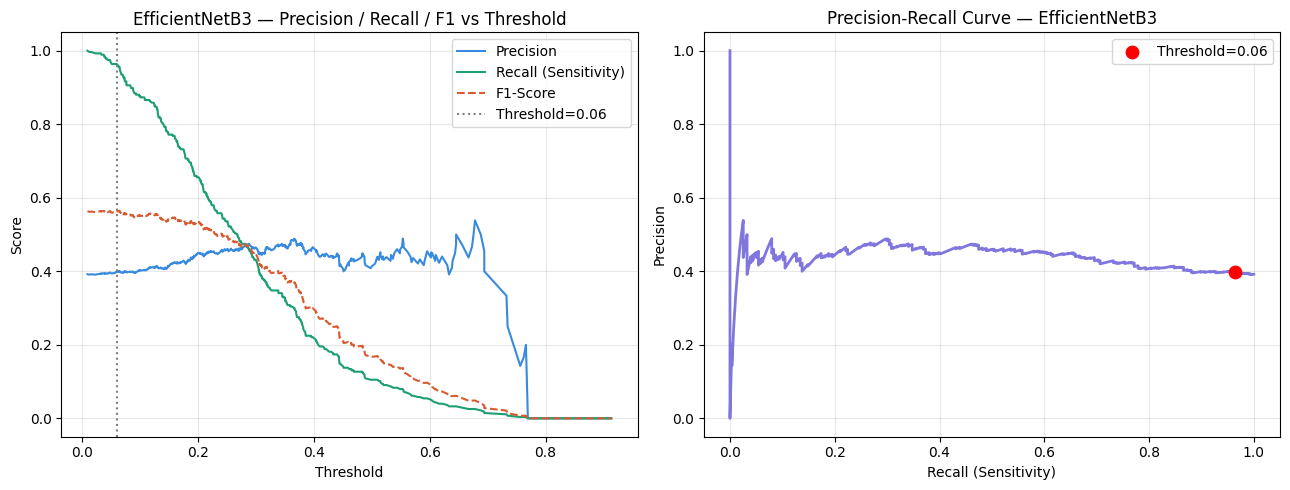


  EfficientNetB3 — Hasil Evaluasi (threshold=0.06)
  Sensitivity (Recall) : 0.9601
  Specificity          : 0.0654
  AUC (ROC)            : 0.5692

              precision    recall  f1-score   support

      Benign       0.72      0.07      0.12       428
   Malignant       0.40      0.96      0.56       276

    accuracy                           0.42       704
   macro avg       0.56      0.51      0.34       704
weighted avg       0.59      0.42      0.29       704



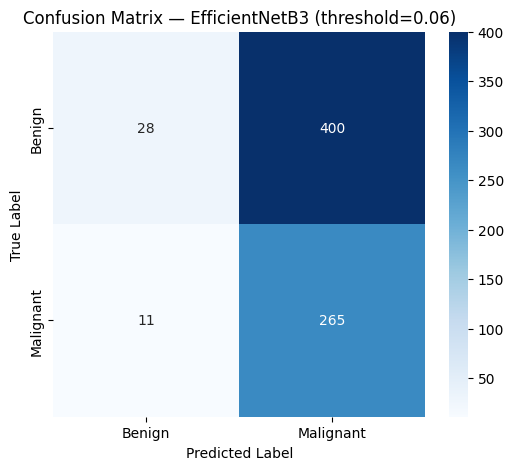

metrics_eff siap untuk perbandingan final.


In [11]:
# ── Evaluasi dengan optimal threshold ──
from sklearn.metrics import precision_recall_curve, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns

y_true_all  = np.concatenate([y for _, y in test_ds], axis=0)
y_pred_prob = model_eff.predict(test_ds).flatten()

# Cari threshold optimal via F1
precision_arr, recall_arr, thresholds = precision_recall_curve(y_true_all, y_pred_prob)
f1_scores     = 2 * (precision_arr[:-1] * recall_arr[:-1]) /                 (precision_arr[:-1] + recall_arr[:-1] + 1e-8)
best_idx      = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f'Threshold optimal: {best_threshold:.3f}  (F1={f1_scores[best_idx]:.4f})')

# Plot PR curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(thresholds, precision_arr[:-1], label='Precision', color='#378ADD')
axes[0].plot(thresholds, recall_arr[:-1],    label='Recall (Sensitivity)', color='#1D9E75')
axes[0].plot(thresholds, f1_scores,          label='F1-Score', color='#D85A30', linestyle='--')
axes[0].axvline(x=best_threshold, color='gray', linestyle=':', label=f'Threshold={best_threshold:.2f}')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('EfficientNetB3 — Precision / Recall / F1 vs Threshold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(recall_arr, precision_arr, color='#7F77DD', linewidth=2)
axes[1].scatter(recall_arr[best_idx], precision_arr[best_idx],
                color='red', zorder=5, s=80, label=f'Threshold={best_threshold:.2f}')
axes[1].set_xlabel('Recall (Sensitivity)'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — EfficientNetB3')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Evaluasi dengan threshold optimal
y_pred_opt  = (y_pred_prob > best_threshold).astype(int)
cm = confusion_matrix(y_true_all, y_pred_opt)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)
auc_score   = roc_auc_score(y_true_all, y_pred_prob)

print(f'\n{"="*50}')
print(f'  EfficientNetB3 — Hasil Evaluasi (threshold={best_threshold:.2f})')
print(f'{"="*50}')
print(f'  Sensitivity (Recall) : {sensitivity:.4f}')
print(f'  Specificity          : {specificity:.4f}')
print(f'  AUC (ROC)            : {auc_score:.4f}')
print(f'\n{classification_report(y_true_all, y_pred_opt, target_names=["Benign","Malignant"])}')

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.title(f'Confusion Matrix — EfficientNetB3 (threshold={best_threshold:.2f})')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.show()

# GradCAM
def get_gradcam(img_array, model, last_conv_layer_name=None):
    # Cari conv layer — termasuk di dalam nested/sub-model
    target_layer = None
    if last_conv_layer_name:
        target_layer = model.get_layer(last_conv_layer_name)
    else:
        for layer in reversed(model.layers):
            # Cek layer langsung
            if isinstance(layer, tf.keras.layers.Conv2D):
                target_layer = layer
                break
            # Cek di dalam sub-model (nested model seperti EfficientNetB3)
            if hasattr(layer, 'layers'):
                for sub_layer in reversed(layer.layers):
                    if isinstance(sub_layer, tf.keras.layers.Conv2D):
                        target_layer = sub_layer
                        break
            if target_layer:
                break

    if target_layer is None:
        print('Grad-CAM: tidak ada Conv2D layer ditemukan, skip.')
        return None

    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[target_layer.output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = tf.reduce_mean(predictions)

    grads   = tape.gradient(loss, conv_outputs)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def show_gradcam(model, dataset, model_name='Model'):
    for images, labels in dataset.take(1):
        sample_img   = images[0:1]
        sample_label = labels[0].numpy()
        break

    heatmap = get_gradcam(sample_img, model)
    if heatmap is None:
        return

    img_np  = sample_img[0].numpy()
    resized = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy()

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title(f"Original — {'Malignant' if sample_label==1 else 'Benign'}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_np)
    plt.imshow(resized, alpha=0.5, cmap='jet')
    plt.title(f'Grad-CAM — {model_name}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Simpan metrik untuk perbandingan final
metrics_eff = {'sensitivity': sensitivity, 'specificity': specificity, 'auc': auc_score}
print('metrics_eff siap untuk perbandingan final.')


# ═══════════════════════════════════════════════════════
# MODEL 2 · ResNet50V2
# Residual connections — stabil dan mudah di-fine-tune
# ═══════════════════════════════════════════════════════


In [12]:
from tensorflow.keras.applications import ResNet50V2

print('Membangun ResNet50V2...')

base_resnet = ResNet50V2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_resnet.trainable = False

x = base_resnet.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out_res = layers.Dense(1, activation='sigmoid', name='output_resnet')(x)

model_res = compile_model(
    Model(inputs=base_resnet.input, outputs=out_res, name='ResNet50V2')
)

model_res.summary()


Membangun ResNet50V2...


Model: "ResNet50V2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,097,793 (91.93 MB)

 Trainable params: 528,897 (2.02 MB)

 Non-trainable params: 23,568,896 (89.91 MB)

=== ResNet50V2 — Tahap 1: Feature Extraction ===
Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.5632 - auc: 0.5650 - loss: 0.8132 - precision: 0.4695 - recall: 0.4564 - val_accuracy: 0.5710 - val_auc: 0.5806 - val_loss: 0.7017 - val_precision: 0.4572 - val_recall: 0.5036 - learning_rate: 1.0000e-04
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.5964 - auc: 0.6033 - loss: 0.7670 - precision: 0.5121 - recall: 0.4496 - val_accuracy: 0.5895 - val_auc: 0.5765 - val_loss: 0.6964 - val_precision: 0.4757 - val_recall: 0.4601 - learning_rate: 1.0000e-04
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.5908 - auc: 0.6057 - loss: 0.7609 - precision: 0.5042 - recall: 0.4564 - val_accuracy: 0.5668 - val_auc: 0.5709 - val_loss: 0.7248 - val_precision: 0.4521 - val_recall: 0.4964 - learning_rate: 1.0000e-04
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.5967 - auc: 0.6106 - loss: 0.7578 - precision: 0.5125 - recall: 0.4505 - val_ac

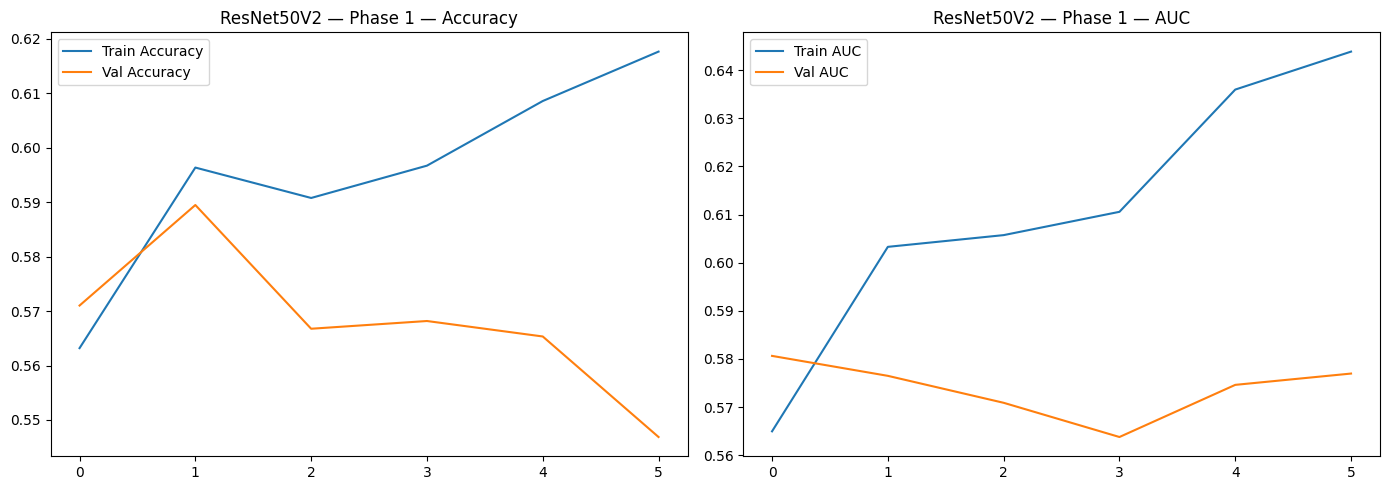

In [13]:
# ── Tahap 1: Feature Extraction ──
print('=== ResNet50V2 — Tahap 1: Feature Extraction ===')
history_res_1 = model_res.fit(
    augmented_train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('resnet50v2_phase1')
)
plot_history(history_res_1, 'ResNet50V2 — Phase 1')


=== ResNet50V2 — Tahap 2: Fine-tuning ===
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.5663 - auc: 0.5688 - loss: 0.8045 - precision: 0.4725 - recall: 0.4445 - val_accuracy: 0.5966 - val_auc: 0.5778 - val_loss: 0.7009 - val_precision: 0.4845 - val_recall: 0.4529 - learning_rate: 1.0000e-05
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.5876 - auc: 0.5904 - loss: 0.7826 - precision: 0.5000 - recall: 0.4666 - val_accuracy: 0.5724 - val_auc: 0.5776 - val_loss: 0.7211 - val_precision: 0.4542 - val_recall: 0.4493 - learning_rate: 1.0000e-05
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.5814 - auc: 0.5883 - loss: 0.7893 - precision: 0.4918 - recall: 0.4581 - val_accuracy: 0.5568 - val_auc: 0.5816 - val_loss: 0.7394 - val_precision: 0.4384 - val_recall: 0.4638 - learning_rate: 1.0000e-05
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.6006 - auc: 0.6100 - loss: 0.7642 - precision: 0.5171 - recall: 0.4742 - val_accuracy:

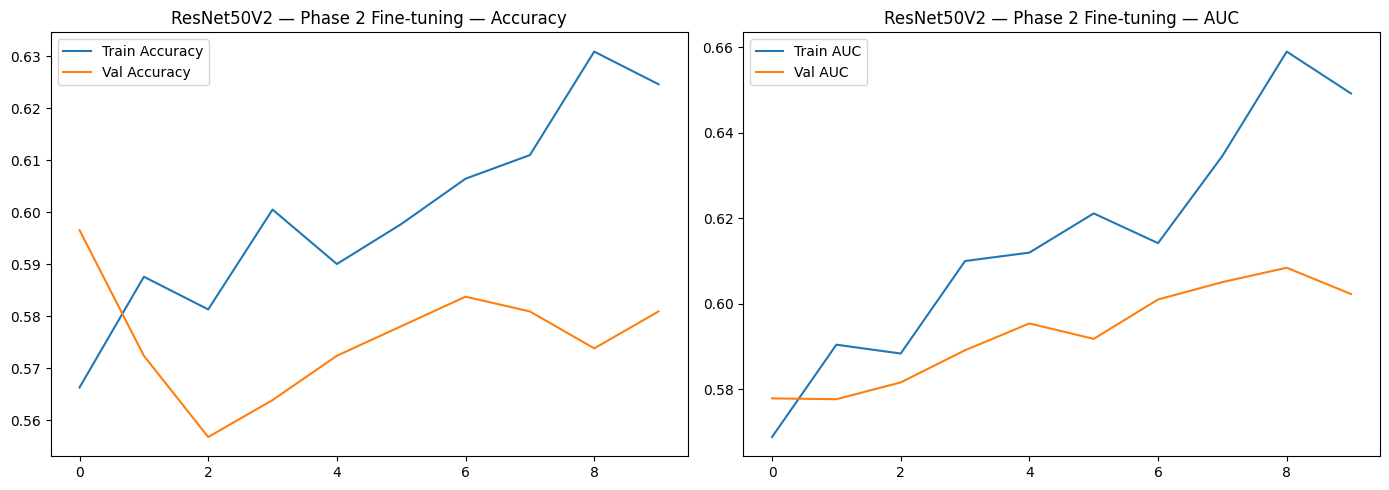

In [14]:
# ── Tahap 2: Fine-tuning — Unfreeze dari 'conv5_block1' ke atas ──
print('=== ResNet50V2 — Tahap 2: Fine-tuning ===')

base_resnet.trainable = True
fine_tune_at = 'conv5_block1_1_conv'  # Layer awal conv5
unfreeze = False
for layer in base_resnet.layers:
    if layer.name == fine_tune_at:
        unfreeze = True
    layer.trainable = unfreeze

model_res.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

history_res_2 = model_res.fit(
    augmented_train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=get_callbacks('resnet50v2_phase2')
)
plot_history(history_res_2, 'ResNet50V2 — Phase 2 Fine-tuning')


22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step

  ResNet50V2 — Hasil Evaluasi
  Sensitivity (Recall) : 0.4529
  Specificity          : 0.6519
  AUC (ROC)            : 0.6084

              precision    recall  f1-score   support

      Benign       0.65      0.65      0.65       428
   Malignant       0.46      0.45      0.45       276

    accuracy                           0.57       704
   macro avg       0.55      0.55      0.55       704
weighted avg       0.57      0.57      0.57       704



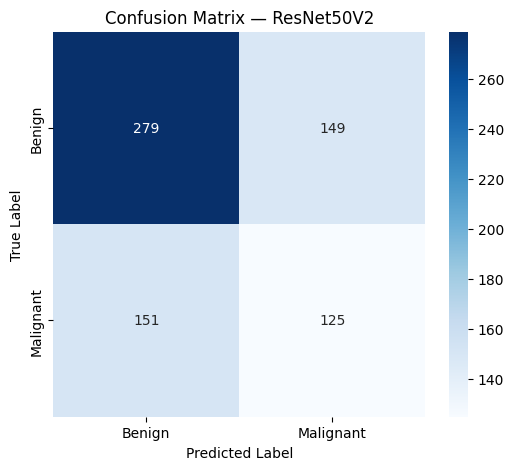

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_397']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


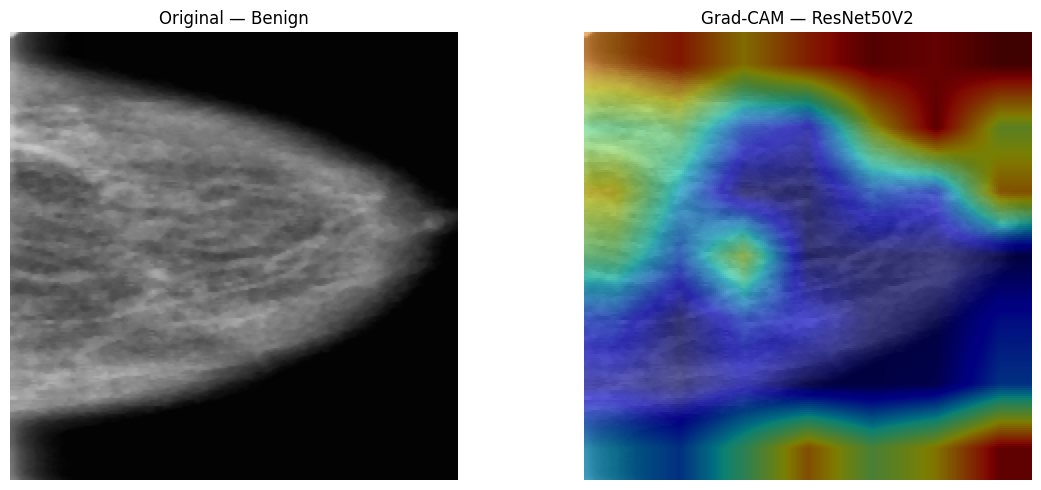

In [15]:
# ── Evaluasi ResNet50V2 ──
metrics_res = evaluate_model(model_res, test_ds, 'ResNet50V2')
show_gradcam(model_res, test_ds, 'ResNet50V2')


# ═══════════════════════════════════════════════════════
# MODEL 3 · MobileNetV2
# Inverted residuals — ringan, cocok untuk prototype cepat
# ═══════════════════════════════════════════════════════


In [16]:
from tensorflow.keras.applications import MobileNetV2

print('Membangun MobileNetV2...')

base_mobile = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    alpha=1.0  # width multiplier: turunkan ke 0.75 jika GPU terbatas
)
base_mobile.trainable = False

x = base_mobile.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)  # Lebih kecil, sesuai kapasitas model
x = layers.Dropout(0.3)(x)
out_mob = layers.Dense(1, activation='sigmoid', name='output_mobilenet')(x)

model_mob = compile_model(
    Model(inputs=base_mobile.input, outputs=out_mob, name='MobileNetV2')
)

model_mob.summary()


Membangun MobileNetV2...


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

=== MobileNetV2 — Tahap 1: Feature Extraction ===
Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 82s 759ms/step - accuracy: 0.5136 - auc: 0.5407 - loss: 0.8593 - precision: 0.4352 - recall: 0.6029 - val_accuracy: 0.6065 - val_auc: 0.5265 - val_loss: 0.6894 - val_precision: 0.4933 - val_recall: 0.1341 - learning_rate: 1.0000e-04
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 79s 761ms/step - accuracy: 0.5733 - auc: 0.5844 - loss: 0.7580 - precision: 0.4826 - recall: 0.4826 - val_accuracy: 0.5824 - val_auc: 0.5489 - val_loss: 0.6958 - val_precision: 0.4595 - val_recall: 0.3696 - learning_rate: 1.0000e-04
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 78s 754ms/step - accuracy: 0.5901 - auc: 0.6054 - loss: 0.7341 - precision: 0.5034 - recall: 0.4445 - val_accuracy: 0.5710 - val_auc: 0.5662 - val_loss: 0.7126 - val_precision: 0.4583 - val_recall: 0.5181 - learning_rate: 1.0000e-04
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 77s 751ms/step - accuracy: 0.5908 - auc: 0.6035 - loss: 0.7295 - precision: 0.5042 - recall: 0.4606

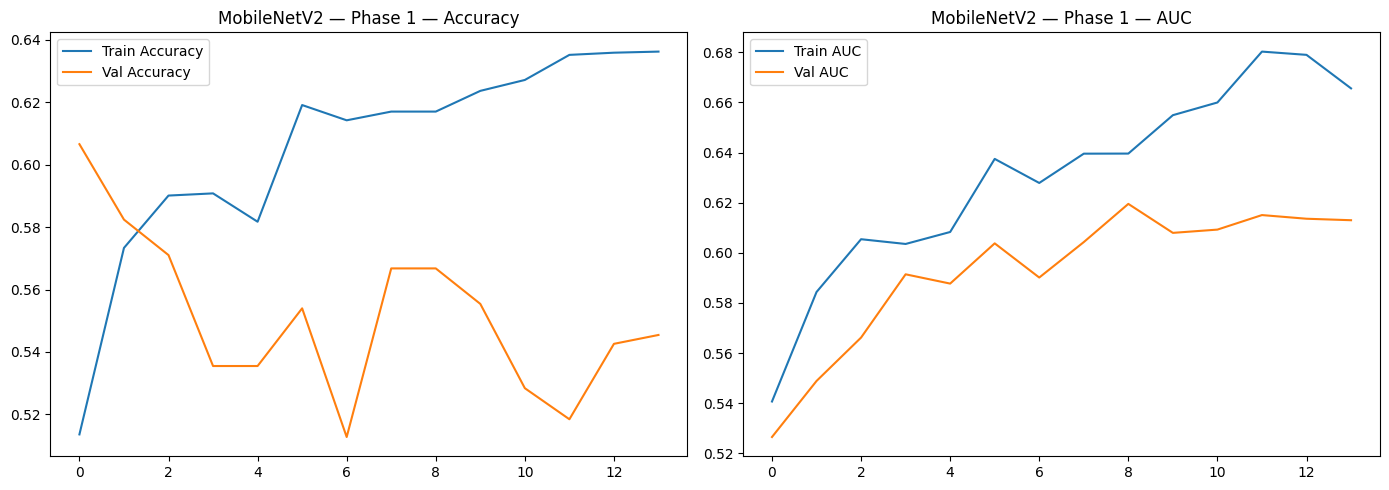

In [17]:
# ── Tahap 1: Feature Extraction ──
print('=== MobileNetV2 — Tahap 1: Feature Extraction ===')
history_mob_1 = model_mob.fit(
    augmented_train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('mobilenetv2_phase1')
)
plot_history(history_mob_1, 'MobileNetV2 — Phase 1')


=== MobileNetV2 — Tahap 2: Fine-tuning ===
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 91s 830ms/step - accuracy: 0.5772 - auc: 0.6034 - loss: 0.7355 - precision: 0.4881 - recall: 0.5216 - val_accuracy: 0.6278 - val_auc: 0.6383 - val_loss: 0.7184 - val_precision: 0.6207 - val_recall: 0.1304 - learning_rate: 2.0000e-05
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 83s 815ms/step - accuracy: 0.5967 - auc: 0.6126 - loss: 0.7190 - precision: 0.5114 - recall: 0.4928 - val_accuracy: 0.6222 - val_auc: 0.6405 - val_loss: 0.7677 - val_precision: 0.6316 - val_recall: 0.0870 - learning_rate: 2.0000e-05
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 83s 814ms/step - accuracy: 0.6156 - auc: 0.6377 - loss: 0.6922 - precision: 0.5381 - recall: 0.4784 - val_accuracy: 0.6122 - val_auc: 0.6523 - val_loss: 0.8541 - val_precision: 0.5882 - val_recall: 0.0362 - learning_rate: 2.0000e-05
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 83s 817ms/step - accuracy: 0.6170 - auc: 0.6517 - loss: 0.6837 - precision: 0.5387 - recall: 0.4945 - val_

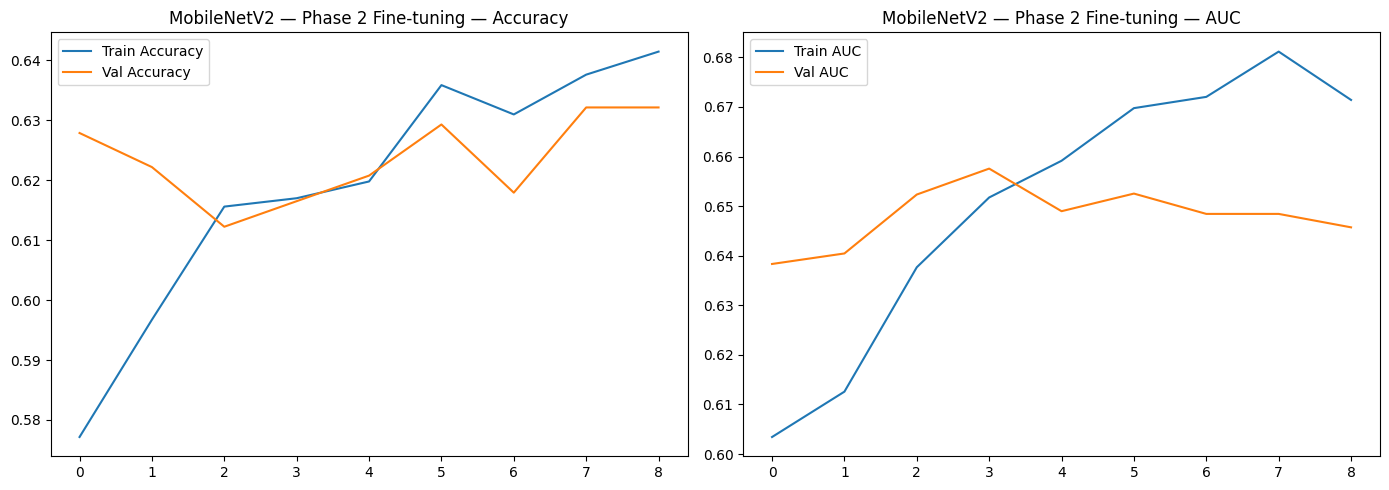

In [18]:
# ── Tahap 2: Fine-tuning — Unfreeze 20 layer terakhir ──
print('=== MobileNetV2 — Tahap 2: Fine-tuning ===')

base_mobile.trainable = True
for layer in base_mobile.layers[:-20]:
    layer.trainable = False

model_mob.compile(
    optimizer=optimizers.Adam(learning_rate=2e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

history_mob_2 = model_mob.fit(
    augmented_train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=get_callbacks('mobilenetv2_phase2')
)
plot_history(history_mob_2, 'MobileNetV2 — Phase 2 Fine-tuning')


22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 623ms/step

  MobileNetV2 — Hasil Evaluasi
  Sensitivity (Recall) : 0.0543
  Specificity          : 0.9790
  AUC (ROC)            : 0.6574

              precision    recall  f1-score   support

      Benign       0.62      0.98      0.76       428
   Malignant       0.62      0.05      0.10       276

    accuracy                           0.62       704
   macro avg       0.62      0.52      0.43       704
weighted avg       0.62      0.62      0.50       704



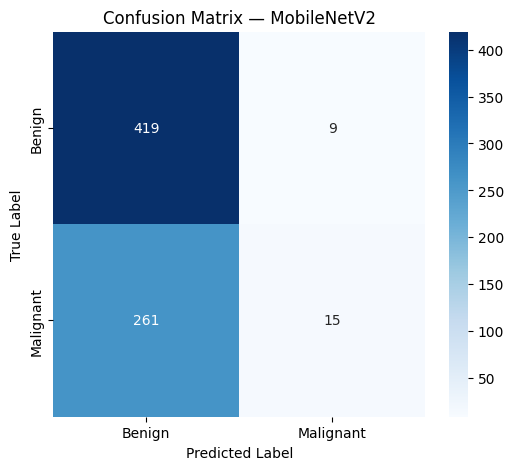

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_592']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


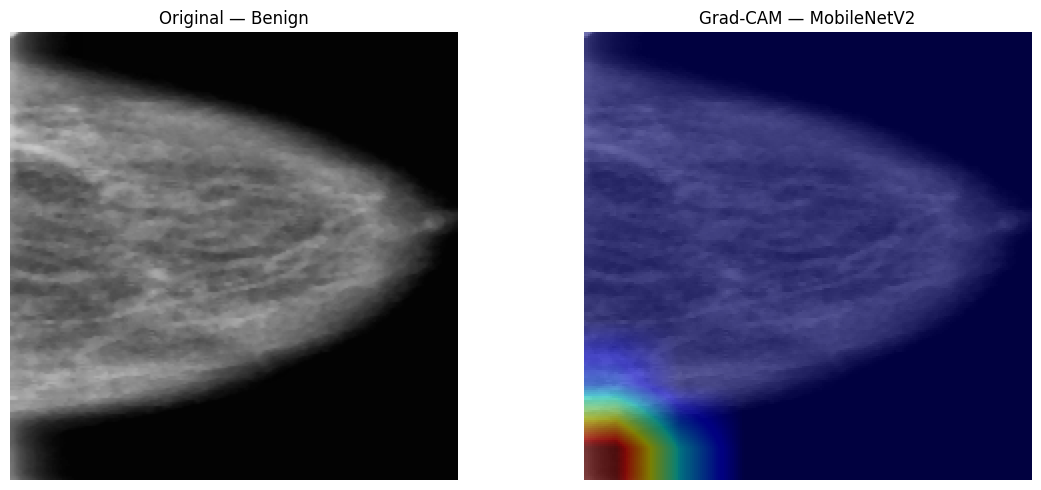

In [19]:
# ── Evaluasi MobileNetV2 ──
metrics_mob = evaluate_model(model_mob, test_ds, 'MobileNetV2')
show_gradcam(model_mob, test_ds, 'MobileNetV2')


# ═══════════════════════════════════════════════════════
# MODEL 4 · DenseNet121
# Dense connections — propagasi fitur optimal untuk medical imaging
# ═══════════════════════════════════════════════════════

In [20]:
from tensorflow.keras.applications import DenseNet121

print('Membangun DenseNet121...')

base_densenet = DenseNet121(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_densenet.trainable = False

x = base_densenet.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out_dns = layers.Dense(1, activation='sigmoid', name='output_densenet')(x)

model_dns = compile_model(
    Model(inputs=base_densenet.input, outputs=out_dns, name='DenseNet121')
)

model_dns.summary()


Membangun DenseNet121...


Model: "DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,304,257 (27.86 MB)

 Trainable params: 264,705 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

=== DenseNet121 — Tahap 1: Feature Extraction ===
Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.5363 - auc: 0.5395 - loss: 0.7705 - precision: 0.4416 - recall: 0.4708 - val_accuracy: 0.5170 - val_auc: 0.5262 - val_loss: 0.7082 - val_precision: 0.4135 - val_recall: 0.5543 - learning_rate: 1.0000e-04
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.5848 - auc: 0.5954 - loss: 0.7124 - precision: 0.4962 - recall: 0.4378 - val_accuracy: 0.5384 - val_auc: 0.5523 - val_loss: 0.6888 - val_precision: 0.4140 - val_recall: 0.4275 - learning_rate: 1.0000e-04
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.5943 - auc: 0.6114 - loss: 0.7002 - precision: 0.5096 - recall: 0.4276 - val_accuracy: 0.5824 - val_auc: 0.5781 - val_loss: 0.6853 - val_precision: 0.4688 - val_recall: 0.4891 - learning_rate: 1.0000e-04
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.6082 - auc: 0.6323 - loss: 0.6863 - precision: 0.5287 - recall: 0.4598 - val_a

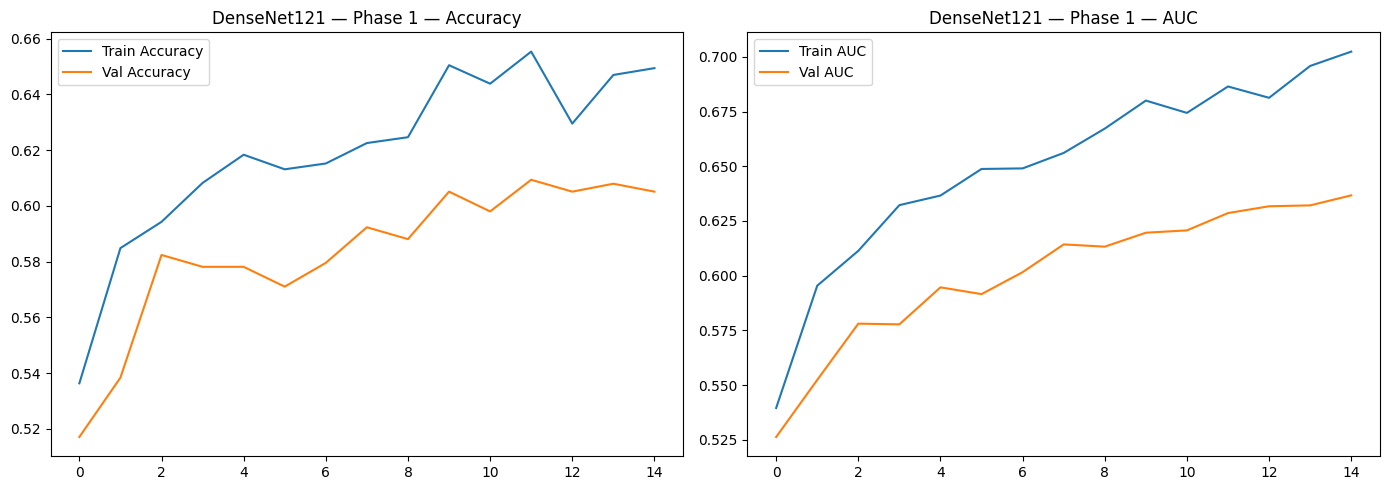

In [21]:
# ── Tahap 1: Feature Extraction ──
print('=== DenseNet121 — Tahap 1: Feature Extraction ===')
history_dns_1 = model_dns.fit(
    augmented_train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('densenet121_phase1')
)
plot_history(history_dns_1, 'DenseNet121 — Phase 1')


=== DenseNet121 — Tahap 2: Fine-tuning ===
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 323s 3s/step - accuracy: 0.6037 - auc: 0.6281 - loss: 0.6801 - precision: 0.5209 - recall: 0.4852 - val_accuracy: 0.5923 - val_auc: 0.6244 - val_loss: 0.6662 - val_precision: 0.4749 - val_recall: 0.3768 - learning_rate: 1.0000e-05
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 288s 3s/step - accuracy: 0.6215 - auc: 0.6553 - loss: 0.6618 - precision: 0.5436 - recall: 0.5123 - val_accuracy: 0.5838 - val_auc: 0.6161 - val_loss: 0.6633 - val_precision: 0.4650 - val_recall: 0.4094 - learning_rate: 1.0000e-05
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 288s 3s/step - accuracy: 0.6226 - auc: 0.6562 - loss: 0.6642 - precision: 0.5441 - recall: 0.5224 - val_accuracy: 0.5895 - val_auc: 0.6126 - val_loss: 0.6650 - val_precision: 0.4737 - val_recall: 0.4239 - learning_rate: 1.0000e-05
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 288s 3s/step - accuracy: 0.6351 - auc: 0.6679 - loss: 0.6543 - precision: 0.5616 - recall: 0.5250 - val_accuracy

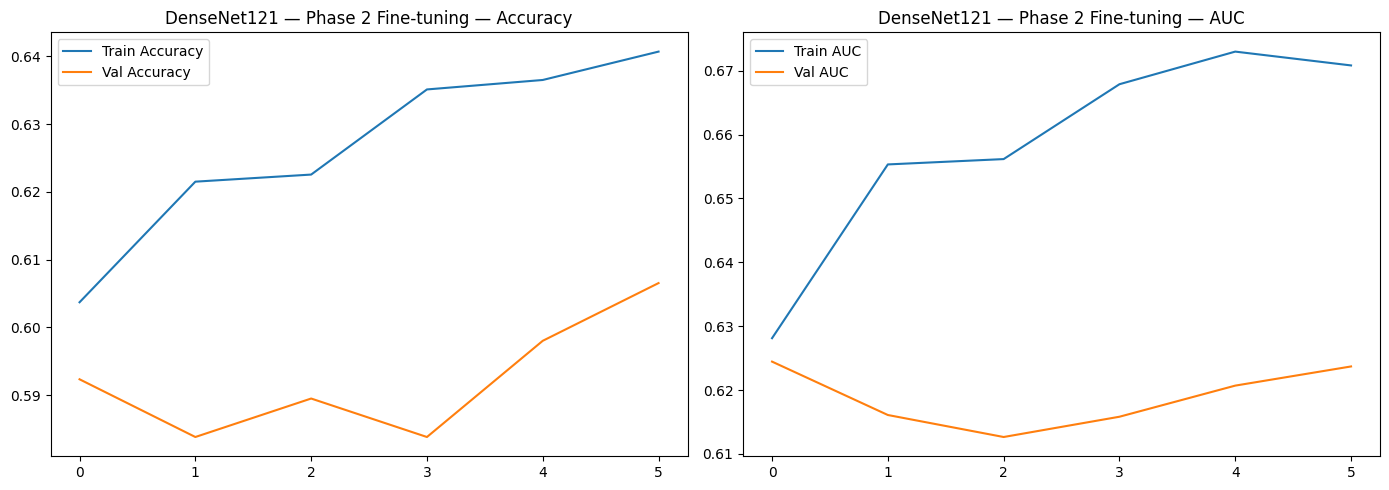

In [22]:
# ── Tahap 2: Fine-tuning — Unfreeze dari 'conv5_block1' ke atas ──
# DenseNet121 memiliki 5 dense block; kita unfreeze dense_block4 & dense_block5
print('=== DenseNet121 — Tahap 2: Fine-tuning ===')

base_densenet.trainable = True
fine_tune_at = 'pool3_pool'   # Mulai unfreeze setelah pool3 (dense_block4+)
unfreeze = False
for layer in base_densenet.layers:
    if layer.name == fine_tune_at:
        unfreeze = True
    layer.trainable = unfreeze

model_dns.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

history_dns_2 = model_dns.fit(
    augmented_train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=get_callbacks('densenet121_phase2')
)
plot_history(history_dns_2, 'DenseNet121 — Phase 2 Fine-tuning')


22/22 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step

  DenseNet121 — Hasil Evaluasi
  Sensitivity (Recall) : 0.3768
  Specificity          : 0.7313
  AUC (ROC)            : 0.6245

              precision    recall  f1-score   support

      Benign       0.65      0.73      0.69       428
   Malignant       0.47      0.38      0.42       276

    accuracy                           0.59       704
   macro avg       0.56      0.55      0.55       704
weighted avg       0.58      0.59      0.58       704



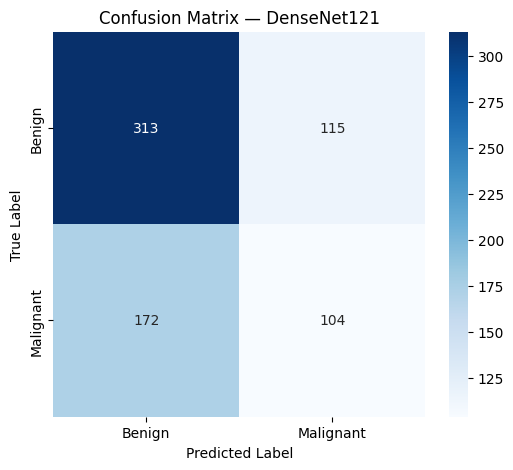

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_751']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


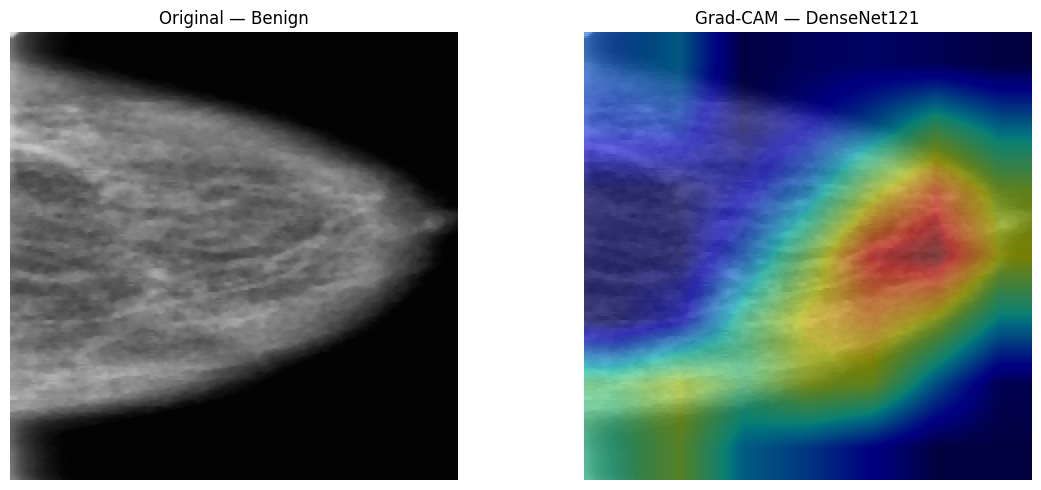

In [23]:
# ── Evaluasi DenseNet121 ──
metrics_dns = evaluate_model(model_dns, test_ds, 'DenseNet121')
show_gradcam(model_dns, test_ds, 'DenseNet121')


## 10 · Perbandingan Final Keempat Model



=== Tabel Perbandingan Model ===
         Model  sensitivity  specificity      auc  overall_score
EfficientNetB3     0.960145     0.065421 0.569162       0.531576
    ResNet50V2     0.452899     0.651869 0.608391       0.571053
   MobileNetV2     0.054348     0.978972 0.657363       0.563561
   DenseNet121     0.376812     0.731308 0.624526       0.577549


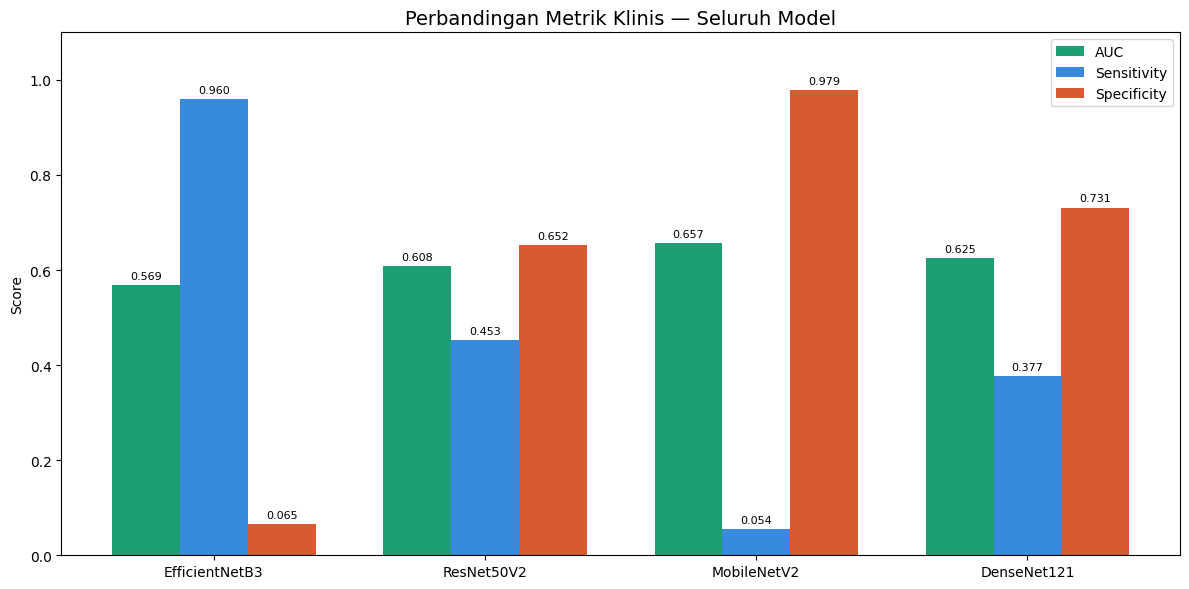

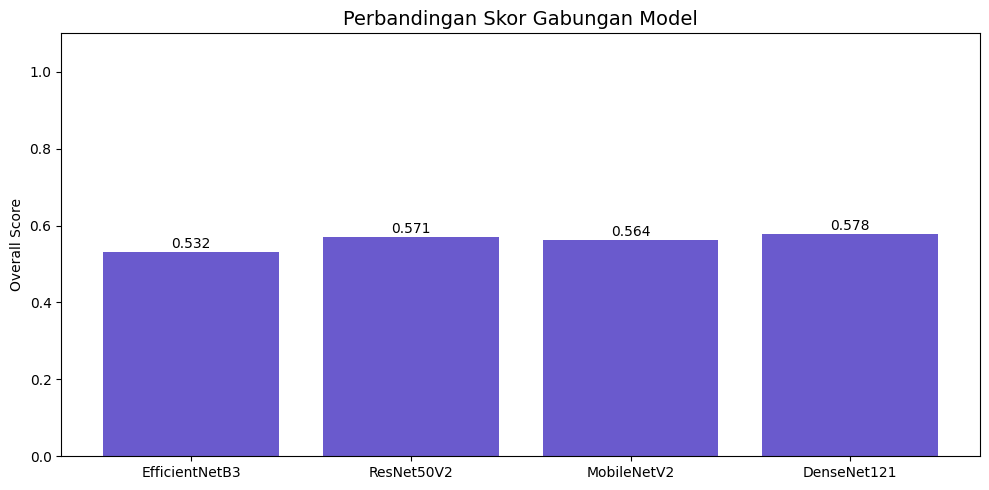


 Model terbaik berdasarkan skor gabungan: DenseNet121 (0.5775)

ANALISIS PERBANDINGAN MODEL

--------------------------------------------------------------------------------
Model : EfficientNetB3
--------------------------------------------------------------------------------
AUC = 0.5692 | Sensitivity = 0.9601 | Specificity = 0.0654 | Overall Score = 0.5316

Kelebihan:
✓ Memiliki sensitivity tertinggi sehingga paling baik mendeteksi kasus positif.

Kekurangan:
✗ AUC masih lebih rendah dibanding MobileNetV2.
✗ Specificity masih lebih rendah dibanding MobileNetV2.

--------------------------------------------------------------------------------
Model : ResNet50V2
--------------------------------------------------------------------------------
AUC = 0.6084 | Sensitivity = 0.4529 | Specificity = 0.6519 | Overall Score = 0.5711

Kelebihan:
✓ Performa cukup baik pada seluruh metrik.

Kekurangan:
✗ AUC masih lebih rendah dibanding MobileNetV2.
✗ Sensitivity masih lebih rendah dibanding Eff

In [24]:
# ── MENYIMPAN HASIL SEMUA MODEL ──

results = {
    'EfficientNetB3': metrics_eff,
    'ResNet50V2':     metrics_res,
    'MobileNetV2':    metrics_mob,
    'DenseNet121':    metrics_dns,
}

df_results = pd.DataFrame(results).T
df_results.index.name = 'Model'
df_results = df_results.reset_index()

# ── MENGHITUNG SKOR GABUNGAN ──

df_results['overall_score'] = (
    df_results['auc'] +
    df_results['sensitivity'] +
    df_results['specificity']
) / 3

print('\n=== Tabel Perbandingan Model ===')
print(df_results.to_string(index=False))

# ── VISUALISASI PERBANDINGAN MODEL ──

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_results))
w = 0.25

colors = ['#1D9E75', '#378ADD', '#D85A30']

b1 = ax.bar(
    x - w,
    df_results['auc'],
    w,
    label='AUC',
    color=colors[0]
)

b2 = ax.bar(
    x,
    df_results['sensitivity'],
    w,
    label='Sensitivity',
    color=colors[1]
)

b3 = ax.bar(
    x + w,
    df_results['specificity'],
    w,
    label='Specificity',
    color=colors[2]
)

ax.set_title(
    'Perbandingan Metrik Klinis — Seluruh Model',
    fontsize=14
)

ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'])

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')

ax.legend()

for bar in [b1, b2, b3]:
    for rect in bar:
        h = rect.get_height()

        ax.annotate(
            f'{h:.3f}',
            xy=(rect.get_x() + rect.get_width()/2, h),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.show()

# ── VISUALISASI SKOR GABUNGAN ──

plt.figure(figsize=(10, 5))

bars = plt.bar(
    df_results['Model'],
    df_results['overall_score'],
    color='#6A5ACD'
)

plt.title(
    'Perbandingan Skor Gabungan Model',
    fontsize=14
)

plt.ylabel('Overall Score')
plt.ylim(0, 1.1)

for bar in bars:
    h = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.01,
        f'{h:.3f}',
        ha='center'
    )

plt.tight_layout()
plt.show()

# ── MENENTUKAN MODEL TERBAIK ──

best_idx = df_results['overall_score'].idxmax()

best_model = df_results.loc[
    best_idx,
    'Model'
]

best_score = df_results.loc[
    best_idx,
    'overall_score'
]

print(
    f'\n Model terbaik berdasarkan skor gabungan: '
    f'{best_model} ({best_score:.4f})'
)

# ── ANALISIS OTOMATIS ──

print('\n' + '='*80)
print('ANALISIS PERBANDINGAN MODEL')
print('='*80)

max_auc_model = df_results.loc[
    df_results['auc'].idxmax(),
    'Model'
]

max_sens_model = df_results.loc[
    df_results['sensitivity'].idxmax(),
    'Model'
]

max_spec_model = df_results.loc[
    df_results['specificity'].idxmax(),
    'Model'
]

for _, row in df_results.iterrows():

    model = row['Model']

    print('\n' + '-'*80)
    print(f'Model : {model}')
    print('-'*80)

    print(
        f"AUC = {row['auc']:.4f} | "
        f"Sensitivity = {row['sensitivity']:.4f} | "
        f"Specificity = {row['specificity']:.4f} | "
        f"Overall Score = {row['overall_score']:.4f}"
    )

    strengths = []
    weaknesses = []

    # ===== KELEBIHAN =====

    if model == max_auc_model:
        strengths.append(
            'Memiliki nilai AUC tertinggi sehingga kemampuan membedakan kelas terbaik.'
        )

    if model == max_sens_model:
        strengths.append(
            'Memiliki sensitivity tertinggi sehingga paling baik mendeteksi kasus positif.'
        )

    if model == max_spec_model:
        strengths.append(
            'Memiliki specificity tertinggi sehingga paling baik mengurangi false positive.'
        )

    if model == best_model:
        strengths.append(
            'Memiliki skor gabungan tertinggi sehingga memberikan performa paling seimbang.'
        )

    # ===== KEKURANGAN =====

    if model != max_auc_model:
        weaknesses.append(
            f'AUC masih lebih rendah dibanding {max_auc_model}.'
        )

    if model != max_sens_model:
        weaknesses.append(
            f'Sensitivity masih lebih rendah dibanding {max_sens_model}.'
        )

    if model != max_spec_model:
        weaknesses.append(
            f'Specificity masih lebih rendah dibanding {max_spec_model}.'
        )

    print('\nKelebihan:')

    if len(strengths) > 0:
        for s in strengths:
            print(f'✓ {s}')
    else:
        print('✓ Performa cukup baik pada seluruh metrik.')

    print('\nKekurangan:')

    if len(weaknesses) > 0:
        for w in weaknesses:
            print(f'✗ {w}')
    else:
        print('✗ Tidak ditemukan kelemahan signifikan.')

# ── RANKING MODEL ──

ranking = df_results.sort_values(
    by='overall_score',
    ascending=False
).reset_index(drop=True)

print('\n' + '='*80)
print('RANKING MODEL')
print('='*80)

for i, row in ranking.iterrows():

    print(
        f"{i+1}. "
        f"{row['Model']} "
        f"(Score = {row['overall_score']:.4f})"
    )

# ── KESIMPULAN AKHIR ──

winner = ranking.iloc[0]
runner_up = ranking.iloc[1]

print('\n' + '='*80)
print('KESIMPULAN')
print('='*80)

print(
    f"Model terbaik adalah {winner['Model']} "
    f"dengan skor gabungan {winner['overall_score']:.4f}."
)

print(
    f"Model ini memperoleh nilai AUC "
    f"{winner['auc']:.4f}, "
    f"Sensitivity {winner['sensitivity']:.4f}, "
    f"dan Specificity {winner['specificity']:.4f}."
)

print(
    f"Posisi kedua ditempati oleh "
    f"{runner_up['Model']} "
    f"dengan skor gabungan "
    f"{runner_up['overall_score']:.4f}."
)

print(
    f"Selisih skor antara kedua model adalah "
    f"{winner['overall_score'] - runner_up['overall_score']:.4f}."
)

print(
    f"Berdasarkan evaluasi gabungan AUC, "
    f"Sensitivity, dan Specificity, "
    f"{winner['Model']} direkomendasikan sebagai "
    f"model utama untuk implementasi klasifikasi kanker payudara."
)

## 11 · Simpan Semua Model


In [25]:
model_eff.save('model_efficientnetb3.keras')
model_res.save('model_resnet50v2.keras')
model_mob.save('model_mobilenetv2.keras')
model_dns.save('model_densenet121.keras')

print('Semua model berhasil disimpan:')
print('  model_efficientnetb3.keras')
print('  model_resnet50v2.keras')
print('  model_mobilenetv2.keras')
print('  model_densenet121.keras')


Semua model berhasil disimpan:
  model_efficientnetb3.keras
  model_resnet50v2.keras
  model_mobilenetv2.keras
  model_densenet121.keras
